# Milestone 4 — QLoRA fine-tuning (Gemma 4 E4B)

## Pre-flight checklist (do BEFORE starting H100)
1. **Push latest code to GitHub** — the clone cell pulls from GitHub; unpushed local fixes won't appear
2. **Create HF model repo** — e.g. `your-username/gemma4-icd-cpt-qlora` (Settings → New model)
3. **Set `HUB_MODEL_ID`** in the config cell below
4. **Runtime → H100 GPU** (A100/T4 also work; batch settings auto-adjust)
5. **HF write token** + **W&B API key** ready
6. Run all cells top → bottom without skipping

Outputs: LoRA adapter on HF Hub + W&B loss curves + local checkpoint

In [1]:
!pip install -q 'transformers>=4.50.0' 'trl>=0.9.0' 'peft>=0.10.0' accelerate bitsandbytes datasets huggingface_hub wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.4/842.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 43.7 MB/s eta 0:00:00


In [2]:
import os
REPO = '/content/clinical-code-extractor'
if not os.path.exists(REPO):
    !git clone https://github.com/namitrathod/clinical-code-extractor.git
else:
    %cd {REPO}
    !git pull --ff-only
%cd /content/clinical-code-extractor

Cloning into 'clinical-code-extractor'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 68 (delta 23), reused 62 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 451.06 KiB | 5.43 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/clinical-code-extractor


In [3]:
import sys
from pathlib import Path

ROOT = Path('/content/clinical-code-extractor')
sys.path.insert(0, str(ROOT))

MODEL_ID = 'google/gemma-4-E4B-it'
HUB_MODEL_ID = 'namitrathod/gemma4-icd-cpt-qlora'  # <-- REQUIRED: change before run

WANDB_PROJECT = 'clinical-code-extractor'
WANDB_RUN_NAME = 'gemma4-icd-cpt-qlora'

NUM_EPOCHS = 2
LEARNING_RATE = 2e-4

# Auto-set batch/seq from GPU (override manually if needed)
import torch
if torch.cuda.is_available():
    _gpu = torch.cuda.get_device_name(0)
    if 'H100' in _gpu or 'A100' in _gpu:
        PER_DEVICE_BATCH, GRAD_ACCUM, MAX_SEQ_LENGTH = 8, 2, 2048
    else:
        PER_DEVICE_BATCH, GRAD_ACCUM, MAX_SEQ_LENGTH = 4, 4, 1024
    print('GPU:', _gpu)
else:
    PER_DEVICE_BATCH, GRAD_ACCUM, MAX_SEQ_LENGTH = 2, 8, 1024
    print('WARNING: no GPU detected — training will fail')

if HUB_MODEL_ID.startswith('your-username'):
    raise ValueError('Set HUB_MODEL_ID to your Hugging Face repo (e.g. namitrathod/gemma4-icd-cpt-qlora)')

print('Model:', MODEL_ID)
print('Hub target:', HUB_MODEL_ID)
print('Batch:', PER_DEVICE_BATCH, 'x accum', GRAD_ACCUM, '=', PER_DEVICE_BATCH * GRAD_ACCUM)
print('Max seq length:', MAX_SEQ_LENGTH)

GPU: NVIDIA A100-SXM4-40GB
Model: google/gemma-4-E4B-it
Hub target: namitrathod/gemma4-icd-cpt-qlora
Batch: 8 x accum 2 = 16
Max seq length: 2048


In [4]:
from huggingface_hub import login, create_repo
import os
import wandb

login()  # HF write token
create_repo(HUB_MODEL_ID, repo_type='model', exist_ok=True)
print('HF repo ready:', HUB_MODEL_ID)

wandb.login()
os.environ['WANDB_PROJECT'] = WANDB_PROJECT

HF repo ready: namitrathod/gemma4-icd-cpt-qlora


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: namitrathod (namit-rathod) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
!python scripts/prepare_training_data.py --spot-check 2

Wrote 4000 train rows -> /content/clinical-code-extractor/data/train_sft.jsonl
Wrote 500 val rows   -> /content/clinical-code-extractor/data/val_sft.jsonl

--- Spot check (prompt + completion should join seamlessly) ---

[note_00427]
:
- "icd10": list of ICD-10-CM code strings
- "cpt": list of CPT code strings
No markdown, no explanations, no other keys.

### Billing codes (JSON only):
{"icd10": ["E11.9"],"cpt": ["99214","83036"]}

[note_01141]
e keys:
- "icd10": list of ICD-10-CM code strings
- "cpt": list of CPT code strings
No markdown, no explanations, no other keys.

### Billing codes (JSON only):
{"icd10": ["G43.909"],"cpt": ["99213"]}


In [6]:
import json
from datasets import load_dataset
from transformers import AutoTokenizer
from src.prompts import format_training_text, format_for_model

train_ds = load_dataset('json', data_files=str(ROOT / 'data/train_sft.jsonl'), split='train')
val_ds = load_dataset('json', data_files=str(ROOT / 'data/val_sft.jsonl'), split='train')
assert len(train_ds) >= 3000, f'Expected ~4000 train rows, got {len(train_ds)}'
assert len(val_ds) >= 400, f'Expected ~500 val rows, got {len(val_ds)}'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# --- pre-flight: token lengths + format sanity ---
lengths = []
for row in train_ds:
    text = format_training_text(tokenizer, row['note'], row['icd10'], row['cpt'])
    lengths.append(len(tokenizer(text, add_special_tokens=False)['input_ids']))
over = sum(1 for n in lengths if n > MAX_SEQ_LENGTH)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Tokens: max={max(lengths)}, p95={sorted(lengths)[int(0.95*len(lengths))]}, over limit={over}')
if over > len(train_ds) * 0.05:
    raise ValueError(f'{over} rows exceed MAX_SEQ_LENGTH={MAX_SEQ_LENGTH} — increase it')

sample = train_ds[0]
assert json.loads(sample['completion'])['icd10'] == sample['icd10']
infer_prefix = format_for_model(tokenizer, sample['note'], tokenize=False)
train_text = format_training_text(tokenizer, sample['note'], sample['icd10'], sample['cpt'])
assert infer_prefix in train_text, 'Inference prompt must match training user turn'
print('Sample completion:', sample['completion'])
print('Pre-flight OK')

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

config.json:   0%|          | 0.00/5.14k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

Train: 4000 | Val: 500
Tokens: max=240, p95=211, over limit=0
Sample completion: {"icd10": ["E11.9"],"cpt": ["99214","83036"]}
Pre-flight OK


In [7]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb,
    device_map='auto',
)

lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules='all-linear',
    task_type='CAUSAL_LM',
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

trainable params: 50,499,584 || all params: 7,991,600,416 || trainable%: 0.6319


In [13]:
from src.prompts import build_user_content, build_completion

def build_training_prompt_completion(note, icd10, cpt):
    return {
        "prompt": [{"role": "user", "content": build_user_content(note)}],
        "completion": [{"role": "assistant", "content": build_completion(icd10, cpt)}],
    }

In [14]:
from datasets import load_dataset

train_ds = load_dataset('json', data_files=str(ROOT / 'data/train_sft.jsonl'), split='train')
val_ds = load_dataset('json', data_files=str(ROOT / 'data/val_sft.jsonl'), split='train')

def to_prompt_completion(batch):
    prompts, completions = [], []
    for n, i, c in zip(batch['note'], batch['icd10'], batch['cpt']):
        pair = build_training_prompt_completion(n, i, c)
        prompts.append(pair['prompt'])
        completions.append(pair['completion'])
    return {'prompt': prompts, 'completion': completions}

train_ds = train_ds.map(to_prompt_completion, batched=True, remove_columns=train_ds.column_names)
val_ds = val_ds.map(to_prompt_completion, batched=True, remove_columns=val_ds.column_names)

print('Columns:', train_ds.column_names)  # MUST print: ['prompt', 'completion']
print('Sample:', train_ds[0]['completion'][0]['content'][:80])

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Columns: ['prompt', 'completion']
Sample: {"icd10": ["E11.9"],"cpt": ["99214","83036"]}


In [15]:
from trl import SFTConfig, SFTTrainer

steps_per_epoch = max(1, len(train_ds) // (PER_DEVICE_BATCH * GRAD_ACCUM))
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = max(1, int(0.05 * total_steps))

training_args = SFTConfig(
    output_dir='checkpoints/gemma4-icd-cpt-qlora',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_steps,          # not warmup_ratio
    lr_scheduler_type='cosine',
    logging_steps=25,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    bf16=True,
    max_length=MAX_SEQ_LENGTH,
    packing=False,
    completion_only_loss=True,
    push_to_hub=True,
    hub_model_id=HUB_MODEL_ID,
    hub_strategy='every_save',
    report_to='wandb',
    run_name=WANDB_RUN_NAME,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    # no formatting_func — uses messages column
)

Tokenizing train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

In [16]:
trainer.train()
trainer.push_to_hub(commit_message='QLoRA clinical coding adapter')
print('Adapter pushed to:', HUB_MODEL_ID)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.061389,0.063699,0.060513,698216.000000,0.965907
2,0.051944,0.057037,0.058614,1396432.000000,0.967122


Adapter pushed to: namitrathod/gemma4-icd-cpt-qlora


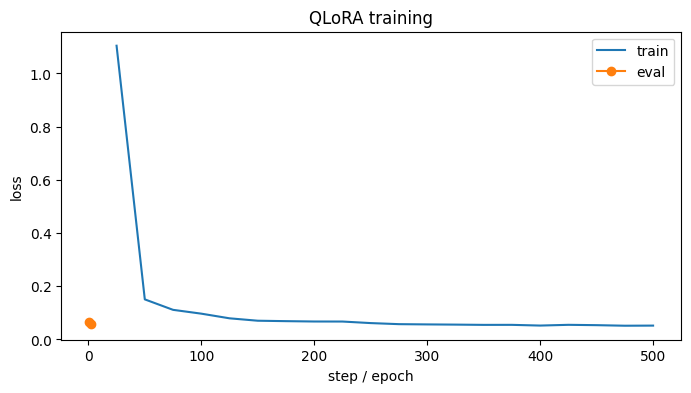

Saved results/train_loss.png


In [17]:
import matplotlib.pyplot as plt
from pathlib import Path
Path('results').mkdir(exist_ok=True)

history = trainer.state.log_history
train_loss = [(h['step'], h['loss']) for h in history if 'loss' in h]
eval_loss = [(h['epoch'], h['eval_loss']) for h in history if 'eval_loss' in h]

if train_loss:
    plt.figure(figsize=(8, 4))
    plt.plot([x[0] for x in train_loss], [x[1] for x in train_loss], label='train')
    if eval_loss:
        plt.plot([x[0] for x in eval_loss], [x[1] for x in eval_loss], 'o-', label='eval')
    plt.xlabel('step / epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.title('QLoRA training')
    plt.savefig('results/train_loss.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved results/train_loss.png')

## Smoke test — 3 held-out notes

Valid JSON with whitelisted codes → proceed to Milestone 5 eval.

In [20]:
import gc
import json
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from scripts.run_baseline import generate_one
from src.validate import load_whitelists, process_model_output

# Free trainer — in-memory PEFT model breaks generate on Gemma
del trainer
gc.collect()
torch.cuda.empty_cache()

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, quantization_config=bnb, device_map='auto')
ft_model = PeftModel.from_pretrained(base, training_args.output_dir)
ft_model.eval()

icd_w, cpt_w = load_whitelists(ROOT / 'codes')
test_rows = [json.loads(l) for l in open(ROOT / 'data/test.jsonl')][:3]

for row in test_rows:
    raw = generate_one(ft_model, tokenizer, row['note'], max_new_tokens=256)
    result = process_model_output(raw, icd_w, cpt_w)
    print('---', row['id'], '---')
    print('Gold ICD:', row['icd10'], '| CPT:', row['cpt'])
    print('Pred ICD:', result['icd10'], '| CPT:', result['cpt'])
    print('JSON valid:', result['json_valid'])
    print('Raw:', raw[:200])

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- note_04828 ---
Gold ICD: ['L03.90', 'J06.9'] | CPT: ['99203']
Pred ICD: ['L03.90'] | CPT: ['99203']
JSON valid: True
Raw: {"icd10": ["L03.90"],"cpt": ["99203"]}
--- note_04888 ---
Gold ICD: ['M79.10'] | CPT: ['99202']
Pred ICD: ['M79.10'] | CPT: ['99204']
JSON valid: True
Raw: {"icd10": ["M79.10"],"cpt": ["99204"]}
--- note_04887 ---
Gold ICD: ['M54.50'] | CPT: ['99213']
Pred ICD: ['M54.50'] | CPT: ['99213']
JSON valid: True
Raw: {"icd10": ["M54.50"],"cpt": ["99213"]}


In [21]:
!python scripts/run_finetuned.py \
  --adapter namitrathod/gemma4-icd-cpt-qlora \
  --gold data/test.jsonl \
  --output predictions_finetuned.jsonl

!python scripts/eval.py \
  --predictions predictions_finetuned.jsonl \
  --output results/finetuned.json

Loading base google/gemma-4-E4B-it + adapter namitrathod/gemma4-icd-cpt-qlora...
Loading weights: 100% 2076/2076 [00:04<00:00, 444.10it/s] 
adapter_config.json: 100% 10.1k/10.1k [00:00<00:00, 19.7MB/s]
adapter_model.safetensors: 100% 202M/202M [00:02<00:00, 73.9MB/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
  10/500 (60s)
  20/500 (119s)
  30/500 (187s)
  40/500 (245s)
  50/500 (305s)
  60/500 (368s)
  70/500 (432s)
  80/500 (499s)
  90/500 (567s)
  100/500 (626s)
  110/500 (693s)
  120/500 (754s)
  130/500 (818s)
  140/500 (880s)
  150/500 (947s)
  160/500 (1012s)
  170/500 (1072s)
  180/500 (1139s)
  190/500 (1203s)
  200/500 (126

In [23]:
from google.colab import files
files.download('results/finetuned.json')
files.download('predictions_finetuned.jsonl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>